# Pyramid Chart

This section showcases the pyramid chart. It contains examples of how to create the pyramid chart using the [datachart.charts.PyramidChart](../../../references/charts/#datachart.charts.PyramidChart) function.

A pyramid chart draws exactly two data series as horizontal bars extending in opposite directions from a shared zero line — the classic population-pyramid layout, useful whenever two groups are compared over the same categories.

Looking for a specific customization? Jump straight to the [quick reference](#customizing-the-pyramid-chart), which maps common tasks to the parameter or style attribute that does the job.

As mentioned above, the pyramid charts are created using the `PyramidChart` function found in the [datachart.charts](../../../references/charts/) module. Let's import it:

In [1]:
from datachart.charts import PyramidChart

## Pyramid Chart Input Attributes

The `PyramidChart` function accepts keyword arguments for chart configuration. The main argument is `data`, which contains exactly two lists of data points: the first list is the left side of the pyramid, the second the right. Both sides are supplied as positive values — the chart mirrors the left side itself, and every visible number (value ticks, value labels) shows the absolute value.

Unlike the other chart functions, the axis parameters are spatial: `xlabel`, `xticks`, and `xmax` address the horizontal value axis, and `ylabel` the vertical category axis. The value axis is always symmetric around zero, so there is no `xmin`.

```python
PyramidChart(
    data=[[{                                        # Exactly two lists of data points: [left_side, right_side]
        "label": str,                               # The category label (shared by both sides)
        "y":     Union[int, float],                 # The bar value, positive for both sides
        "yerr":  Optional[Union[int, float]]        # The bar error value
    }], [...]],
    style={                                         # The style of the bars (optional); a list styles each side
        "plot_bar_*": ...,
    },
    subtitle=Optional[List[str]],                   # The names of the two sides, used as legend labels
    title=Optional[str],                            # The title of the chart
    xlabel=Optional[str],                           # The label of the horizontal value axis
    ylabel=Optional[str],                           # The label of the vertical category axis

    figsize=Optional[Tuple[float, float]],          # The figure size in inches
    show_grid=Optional[str],                        # Which grid lines to show ("both", "x", "y")
    show_legend=Optional[bool],                     # Whether to show the legend
    show_yerr=Optional[bool],                       # Whether to show error bars on the bars
    show_values=Optional[bool],                     # Whether to show bar value labels at the bar ends
    value_format=Optional[str],                     # Format of the value labels (VALUE_FORMAT constant or e.g. "{:.1f}%")

    xmax=Optional[Union[int, float]],               # The maximum per-side value; the value axis spans (-xmax, xmax)
    xticks=Optional[List[Union[int, float]]],       # Custom value-axis tick positions, positive; mirrored to both halves
    xticklabels=Optional[List[str]],                # Custom value-axis tick labels, applied to both halves
    xtickrotate=Optional[int],                      # Rotation angle of the value-axis tick labels
    yticks=Optional[List[Union[int, float]]],       # Custom category-axis tick positions
    yticklabels=Optional[List[str]],                # Custom category-axis tick labels
    ytickrotate=Optional[int],                      # Rotation angle of the category-axis tick labels

    vlines=Optional[VLinePlotAttrs],                # The vertical lines to draw
    hlines=Optional[HLinePlotAttrs],                # The horizontal lines to draw

    label=Optional[str],                            # The data key for the labels (default: "label")
    y=Optional[str],                                # The data key for the bar values (default: "y")
    yerr=Optional[str]                              # The data key for the bar errors (default: "yerr")
)
```

For more details, see the [datachart.charts.PyramidChart](../../../references/charts/#datachart.charts.PyramidChart) function.

## Basics

The examples in this guide share one dataset: the resident register of a city's two districts. The data is constructed in a hidden cell; `riverside` and `hillcrest` hold the population by single year of age (0–79, so 160 bars per pyramid), `riverside_bands` and `hillcrest_bands` aggregate the same register into two-year age bands (80 bars, with the register's estimated error as `yerr`), `riverside_2015`/`hillcrest_2015` hold the register a decade earlier, and `station_in`/`station_out` hold metro station passengers per 15-minute slot.

In [2]:
import math

AGES = list(range(80))


def _district(base, boom_age, boom_size, taper, phase):
    side = []
    for age in AGES:
        v = base - age * taper
        v += boom_size * math.exp(-((age - boom_age) ** 2) / 120)
        v += 55 * math.sin(age / 5.5 + phase)
        side.append({"label": str(age), "y": float(round(max(v, 40.0)))})
    return side


def _bands(side, width=2):
    return [
        {
            "label": f"{lo}-{lo + width - 1}",
            "y": sum(p["y"] for p in side[lo : lo + width]),
            "yerr": round(0.04 * sum(p["y"] for p in side[lo : lo + width]), 1),
        }
        for lo in range(0, len(side), width)
    ]


# resident population by single year of age (0-79) in the two districts
riverside = _district(base=920, boom_age=31, boom_size=380, taper=6.5, phase=0.4)
hillcrest = _district(base=860, boom_age=42, boom_size=430, taper=5.8, phase=2.1)

# the same register in two-year age bands, with the estimated error
riverside_bands = _bands(riverside)
hillcrest_bands = _bands(hillcrest)

# the register a decade earlier
riverside_2015 = _district(base=880, boom_age=24, boom_size=340, taper=6.9, phase=1.1)
hillcrest_2015 = _district(base=820, boom_age=33, boom_size=390, taper=6.1, phase=2.8)


# metro station passengers by 15-minute slot (06:00-21:45)
def _flows(morning_peak, evening_peak, phase):
    slots = []
    for i in range(64):
        hour = 6 + i / 4
        v = 40
        v += morning_peak * math.exp(-((hour - 8.25) ** 2) / 1.1)
        v += evening_peak * math.exp(-((hour - 17.5) ** 2) / 1.8)
        v += 18 * math.sin(hour * 1.3 + phase)
        slots.append(
            {"label": f"{int(hour):02d}:{(i % 4) * 15:02d}", "y": float(round(max(v, 5.0)))}
        )
    return slots


station_in = _flows(morning_peak=520, evening_peak=260, phase=0.3)
station_out = _flows(morning_peak=210, evening_peak=540, phase=1.9)

Each data point is a dictionary with a `label` (the age band) and a positive `y` value; the same labels appear on both sides:

In [3]:
riverside_bands[:3]

[{'label': '0-1', 'y': 1886.0, 'yerr': 75.4},
 {'label': '2-3', 'y': 1891.0, 'yerr': 75.6},
 {'label': '4-5', 'y': 1887.0, 'yerr': 75.5}]

**Basic example.** Only the `data` argument is required — exactly two lists of data points, the first drawn to the left and the second to the right.

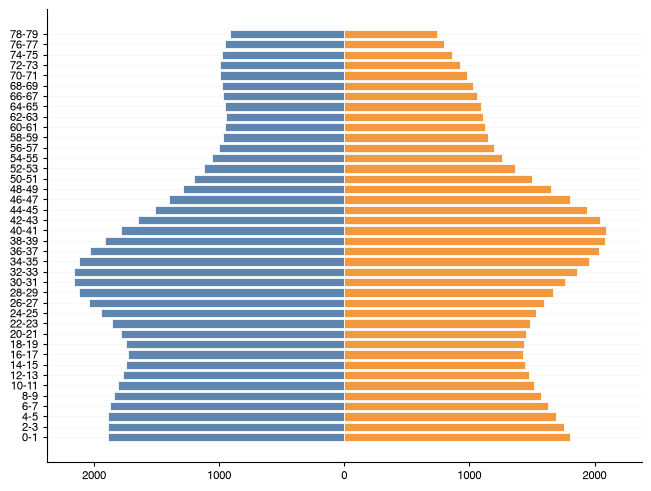

In [4]:
PyramidChart(
    # add the two sides of the pyramid: [left_side, right_side]
    data=[riverside_bands, hillcrest_bands]
).show()

Both sides extend from the shared zero line at full bar width, the category labels sit at the left edge, and the value ticks show absolute values on both halves.

## Customizing the Pyramid Chart

Every customization is either a keyword argument of `PyramidChart` or a style attribute of its `style` dictionary. The table maps common tasks to the one you need and links to the subsection that shows it.

| I want to…                                | Use                                                | See |
| :---------------------------------------- | :------------------------------------------------- | :-- |
| add a title and axis labels               | `title`, `xlabel`, `ylabel`                        | [Title and axis labels](#title-and-axis-labels) |
| name the two sides                        | `subtitle`, `show_legend`                          | [Naming the sides](#naming-the-sides) |
| resize the figure or show the grid        | `figsize`, `show_grid`                             | [Figure size and grid](#figure-size-and-grid) |
| fix the value range or place ticks        | `xmax`, `xticks`, `yticks`                         | [Axis limits and ticks](#axis-limits-and-ticks) |
| write each bar's value at its end         | `show_values`, `value_format`                      | [Value labels](#value-labels) |
| show the error bars                       | `show_yerr`                                        | [Error bars](#error-bars) |
| style the bars, per side                  | `style`                                            | [Bar style](#bar-style) |
| use my own data keys                      | `label`, `y`, `yerr`                               | [Custom data keys](#custom-data-keys) |

### Title and axis labels

To add the chart title and axis labels, add the `title`, `xlabel` and `ylabel` attributes. The axis parameters are spatial: `xlabel` describes the horizontal value axis and `ylabel` the vertical category axis.

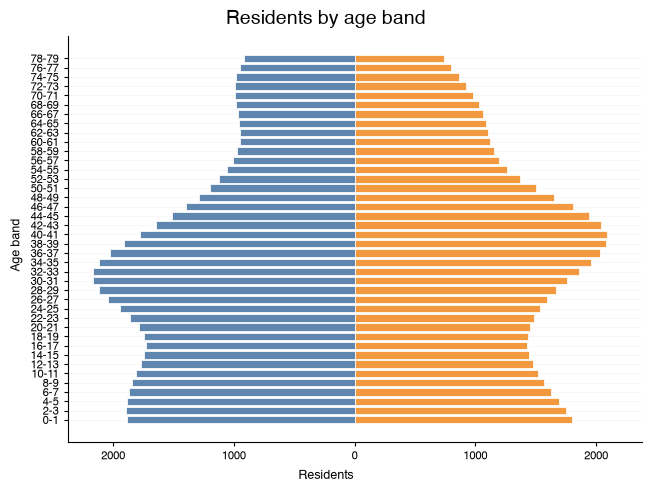

In [5]:
PyramidChart(
    data=[riverside_bands, hillcrest_bands],
    # add the title and the axis labels
    title="Residents by age band",
    xlabel="Residents",
    ylabel="Age band",
).show()

### Naming the sides

The `subtitle` attribute names the two sides, in the same order as `data`; with `show_legend=True` the names appear in the legend.

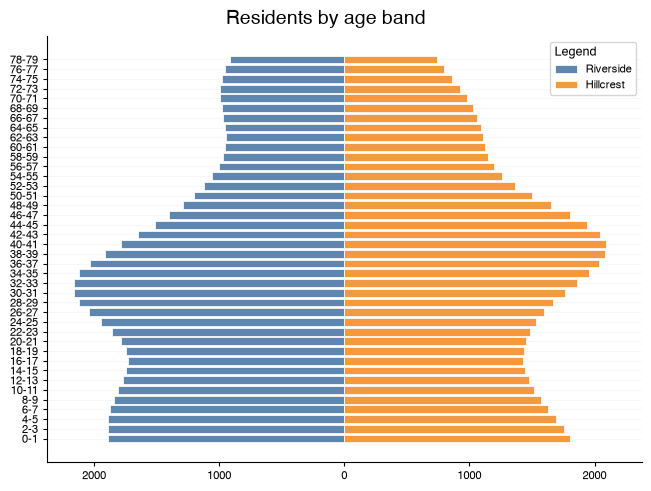

In [6]:
PyramidChart(
    data=[riverside_bands, hillcrest_bands],
    # name the sides and show the legend
    subtitle=["Riverside", "Hillcrest"],
    show_legend=True,
    title="Residents by age band",
).show()

### Figure size and grid

The figure size is set with `figsize` — the [datachart.constants](../../../references/constants) module provides the `FIG_SIZE` options — and the grid is turned on with `show_grid`. On a pyramid the vertical grid lines (`"x"`) are usually the useful ones, since they mark the value steps on both halves; a taller figure gives a dense pyramid's bands room to breathe.

In [7]:
from datachart.constants import FIG_SIZE, SHOW_GRID

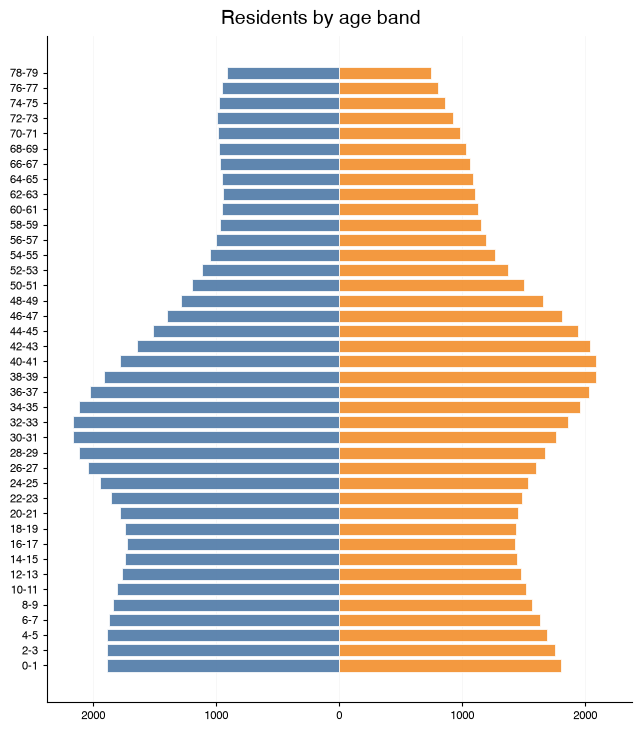

In [8]:
PyramidChart(
    data=[riverside_bands, hillcrest_bands],
    title="Residents by age band",
    # a taller figure and vertical grid lines
    figsize=FIG_SIZE.FULL_TALL,
    show_grid=SHOW_GRID.X,
).show()

### Axis limits and ticks

The value axis is always symmetric around zero. The `xmax` attribute sets the maximum per-side value, so the axis spans `(-xmax, xmax)`; passing `xmin` raises a `ValueError`.

The `xticks` attribute places custom value ticks: the positions are given as positive values and each is mirrored to both halves. The `xticklabels` attribute (same length as `xticks`) replaces the tick labels on both halves, and `xtickrotate` rotates them.

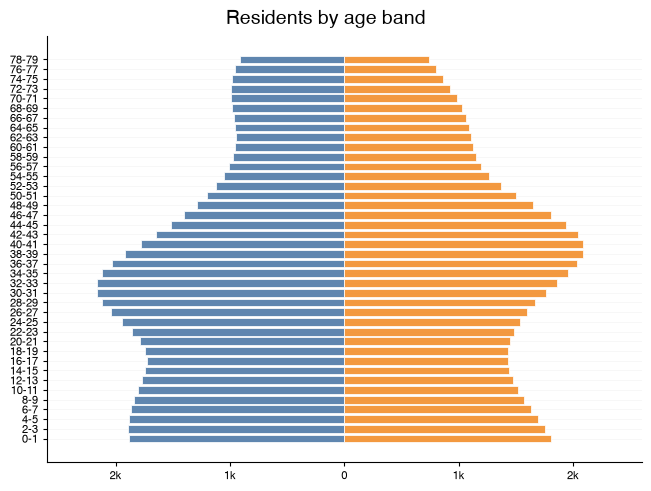

In [9]:
PyramidChart(
    data=[riverside_bands, hillcrest_bands],
    title="Residents by age band",
    # fix the per-side range and label the value axis in thousands
    xmax=2600,
    xticks=[0, 1000, 2000],
    xticklabels=["0", "1k", "2k"],
).show()

The category axis keeps the usual `yticks`, `yticklabels`, and `ytickrotate` controls. They matter most on dense pyramids: the single-year register has 80 bands per side, far too many to label individually, so tick positions every tenth band keep the axis readable.

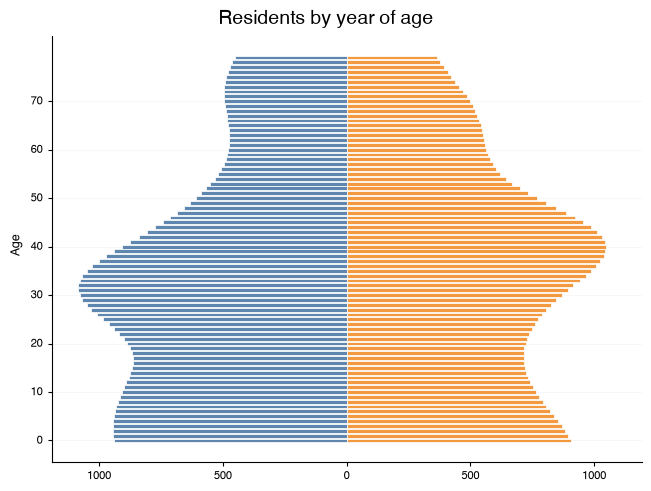

In [10]:
PyramidChart(
    data=[riverside, hillcrest],
    title="Residents by year of age",
    ylabel="Age",
    # 80 single-year bands per side: label every tenth one
    yticks=list(range(0, 80, 10)),
).show()

### Value labels

The `show_values` attribute writes each bar's value at its end, formatted via `value_format` — a `VALUE_FORMAT` constant or any printf/format-style string. The labels show the absolute value on both sides. On a dense pyramid, shrink them with the `plot_bar_value_fontsize` style attribute so the rows stay separate.

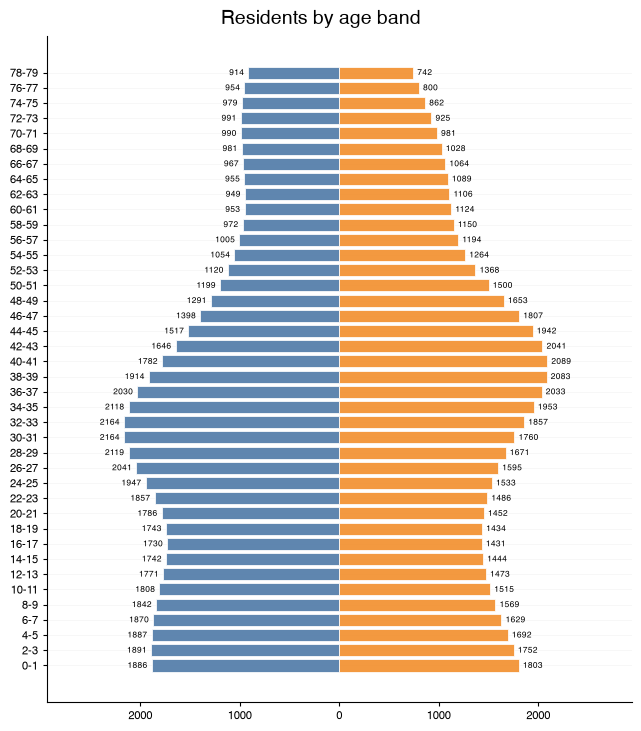

In [11]:
PyramidChart(
    data=[riverside_bands, hillcrest_bands],
    title="Residents by age band",
    # write each bar's count at its end, in a small font
    show_values=True,
    value_format="%.0f",
    style={"plot_bar_value_fontsize": 6},
    figsize=FIG_SIZE.FULL_TALL,
).show()

### Error bars

The `show_yerr` attribute draws the `yerr` values as error bars at the bar ends — on a pyramid they extend along the value axis, symmetrically on both sides of the bar end.

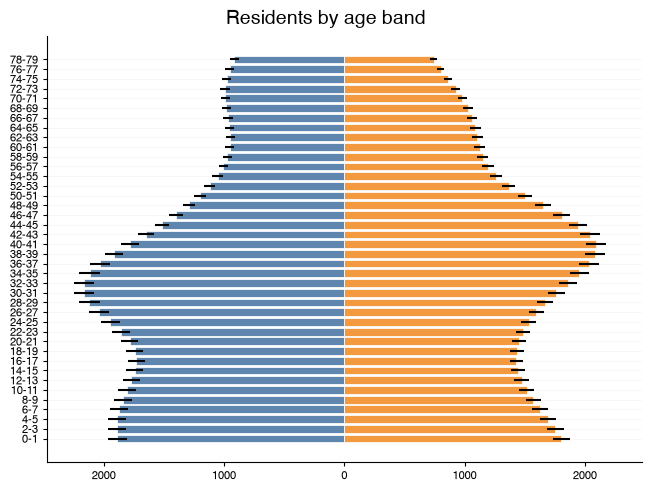

In [12]:
PyramidChart(
    data=[riverside_bands, hillcrest_bands],
    title="Residents by age band",
    # draw the register's estimated error at the bar ends
    show_yerr=True,
).show()

### Bar style

Pyramid bars obey the same `plot_bar_*` style attributes as the bar chart; see the [datachart.typings](../../../references/typings) module for the full family. A single `style` dictionary applies to both sides; a list of two styles the sides individually. Without explicit colors, the two sides take the first two colors of the theme's palette — themes therefore style pyramids out of the box.

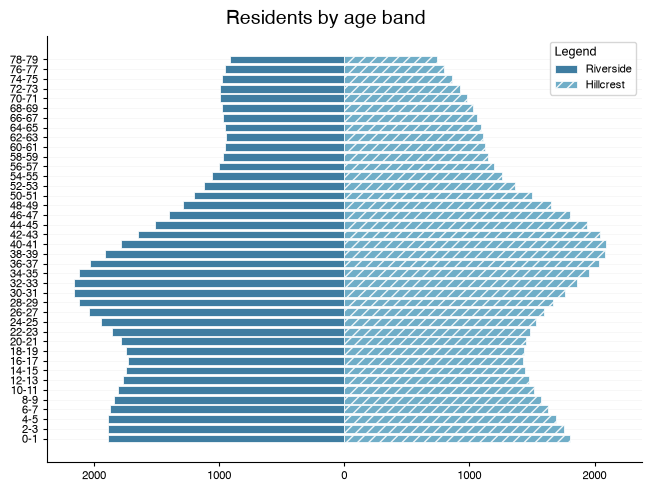

In [13]:
PyramidChart(
    data=[riverside_bands, hillcrest_bands],
    subtitle=["Riverside", "Hillcrest"],
    show_legend=True,
    title="Residents by age band",
    # style each side individually
    style=[
        {"plot_bar_color": "#2a6f97"},
        {"plot_bar_color": "#61a5c2", "plot_bar_hatch": "///"},
    ],
).show()

### Custom data keys

If the data points use different key names, the `label`, `y`, and `yerr` attributes remap them — either one name for both sides or a list of two.

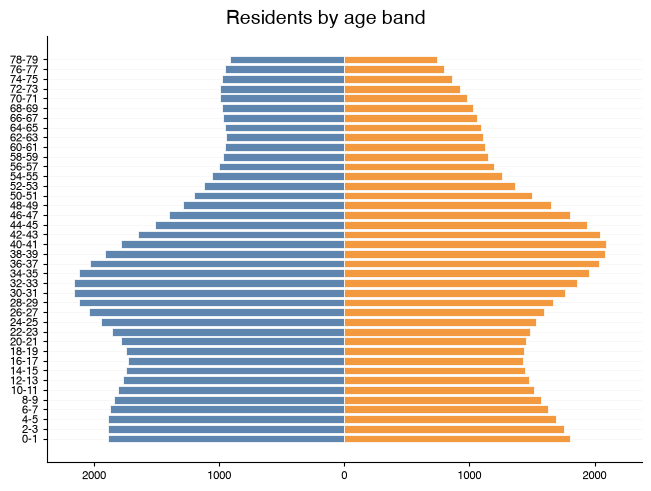

In [14]:
riverside_counts = [
    {"band": p["label"], "residents": p["y"]} for p in riverside_bands
]
hillcrest_counts = [
    {"band": p["label"], "residents": p["y"]} for p in hillcrest_bands
]

PyramidChart(
    data=[riverside_counts, hillcrest_counts],
    # remap the data keys
    label="band",
    y="residents",
    title="Residents by age band",
).show()

## Composing Pyramids

One `PyramidChart` call makes one pyramid. For small multiples, compose rendered figures with [datachart.utils.Grid](../../../references/utils#datachart.utils.Grid) — each pyramid keeps its mirrored axis inside its own cell. Overlaying a pyramid onto other charts with [datachart.utils.Panel](../../../references/utils#datachart.utils.Panel) is not supported and raises a `ValueError`, since unmirrored data on a mirrored axis would be misleading.

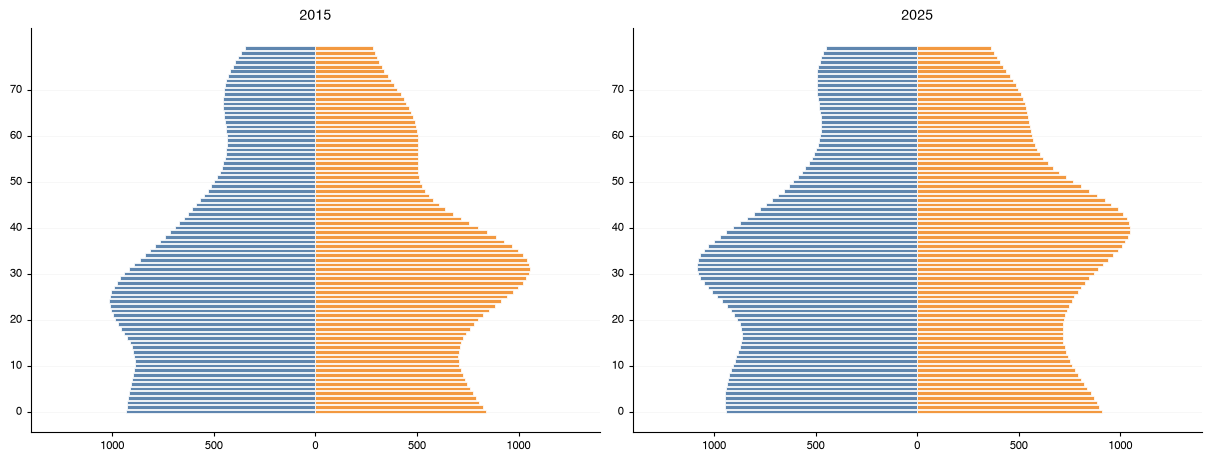

In [15]:
from datachart.utils import Grid

decade_ticks = list(range(0, 80, 10))

Grid(
    [
        PyramidChart(
            data=[riverside_2015, hillcrest_2015],
            subtitle=["Riverside", "Hillcrest"],
            title="2015",
            xmax=1400,
            yticks=decade_ticks,
        ),
        PyramidChart(
            data=[riverside, hillcrest],
            subtitle=["Riverside", "Hillcrest"],
            title="2025",
            xmax=1400,
            yticks=decade_ticks,
        ),
    ],
    max_cols=2,
    figsize=(12, 4.5),
).show()

## Saving the Chart as an Image

To save the chart as an image, use the [datachart.utils.save_figure](../../../references/utils#datachart.utils.save_figure) function.

In [16]:
from datachart.utils import save_figure

In [17]:
figure = PyramidChart(
    data=[riverside_bands, hillcrest_bands],
    title="Residents by age band",
)
save_figure(figure, "./fig_pyramid_chart.png", dpi=300)

The figure should be saved in the current working directory.

## Real-World Examples

### Example 1: Population Pyramid

The classic use: the full single-year register — 160 bars — with named sides, decade ticks, a fixed symmetric range, and vertical grid lines.

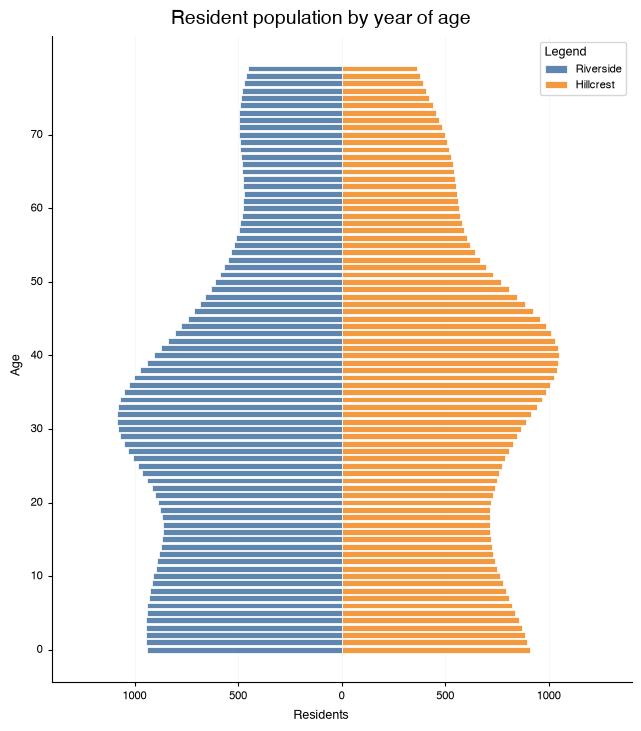

In [18]:
PyramidChart(
    data=[riverside, hillcrest],
    subtitle=["Riverside", "Hillcrest"],
    title="Resident population by year of age",
    xlabel="Residents",
    ylabel="Age",
    xmax=1400,
    yticks=list(range(0, 80, 10)),
    show_legend=True,
    show_grid=SHOW_GRID.X,
    figsize=FIG_SIZE.FULL_TALL,
).show()

### Example 2: Passenger Flows by Time of Day

The same layout works for any two-group comparison over shared categories — here a metro station's entries against exits across 64 quarter-hour slots (128 bars). The morning peak flows in, the evening peak flows out; hourly tick labels keep the time axis readable.

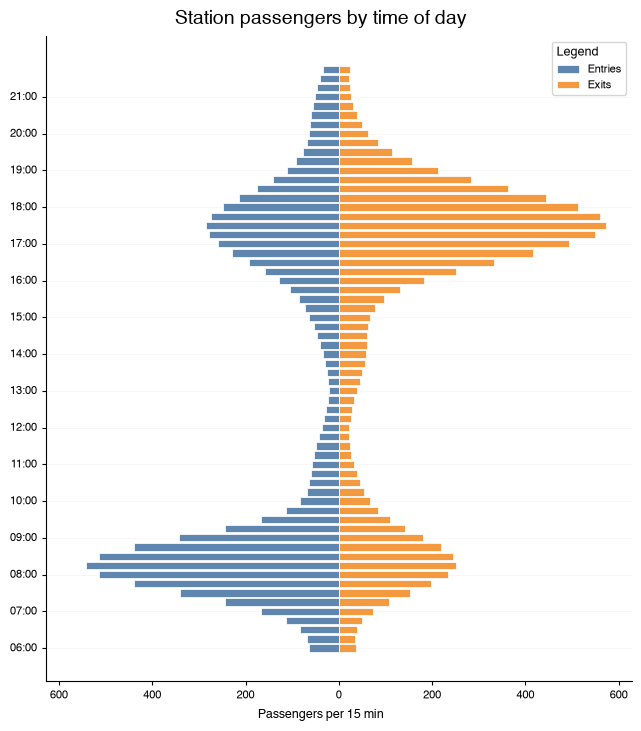

In [19]:
PyramidChart(
    data=[station_in, station_out],
    subtitle=["Entries", "Exits"],
    title="Station passengers by time of day",
    xlabel="Passengers per 15 min",
    # one tick per hour over the 15-minute slots
    yticks=list(range(0, 64, 4)),
    yticklabels=[station_in[i]["label"] for i in range(0, 64, 4)],
    show_legend=True,
    figsize=FIG_SIZE.FULL_TALL,
).show()